# [2주차 과제] 지도학습 모델의 회귀 및 분류 성능 비교

## 과제 목표
- 선형 모델의 한계를 확인하고, 비선형 모델(SVR, Decision Tree, Ensemble)의 성능을 비교합니다.
- 지표 해석, 규제(Regularization), Bias-Variance에 대해 학습합니다.

## 데이터셋
- 회귀: California Housing
- 분류: Wine


## 제출 지침
- 원활한 의존성 라이브러리 사용을 위해 코랩 환경에서 진행하시는 것을 권장합니다.
- 각 문항 아래 코드 셀을 실행하고, `TODO` 주석이 있는 곳을 작성하세요.
    - '___' 부분에 알맞은 코드를 작성하시면 됩니다.
- 문항별 해석(서술형) 문항은 마크다운 셀('답안'으로 명시된 부분)에 작성하세요.


In [2]:
# 공통 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report

# 스타일 및 난수 시드값 고정
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [3]:
# 데이터 로드

# 회귀 문제용 데이터
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data.copy()
y_reg = housing.target.copy()

# 분류 문제용 데이터
wine = load_wine(as_frame=True)
X_clf = wine.data.copy()
y_clf = wine.target.copy()

print('회귀 데이터:', X_reg.shape, y_reg.shape)
print('분류 데이터:', X_clf.shape, y_clf.shape)

회귀 데이터: (20640, 8) (20640,)
분류 데이터: (178, 13) (178,)


## [Section 1] EDA & Preprocessing

### 문제 1
1. 상관관계 Heatmap을 시각화하세요.
2. 타겟과 절대 상관계수가 가장 높은 특성 2개를 확인해보세요.


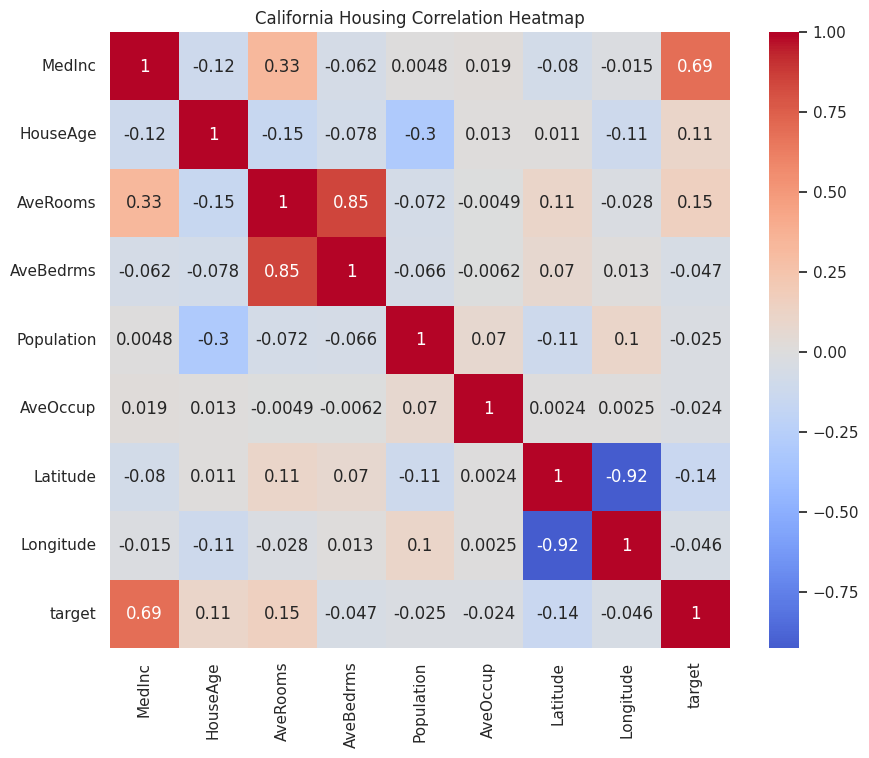

타겟과 상관계수 상위 2개 특성:
MedInc      0.688075
AveRooms    0.151948
Name: target, dtype: float64


In [4]:
# 문제 1: 회귀 데이터 상관관계 분석
reg_df = X_reg.copy()
reg_df['target'] = y_reg

# TODO 1) 상관계수 행렬 계산 메서드
corr = reg_df.corr(numeric_only=True)

# TODO 2) Heatmap 입력 데이터
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('California Housing Correlation Heatmap')
plt.show()

# TODO 3) target과 절대 상관계수 상위 2개 특성 추출
top2 = corr['target'].drop('target').abs().sort_values(ascending=False).head(2)
print('타겟과 상관계수 상위 2개 특성:')
print(top2)


### 문제 1 해석 작성
- (작성) 선택한 2개 특성이 타겟과 연관성이 높은 이유를 데이터셋을 고려하여 추론해보세요.

**답안:**
MedInc는 California Housing 데이터에서 가장 큰 상관관계를 보이는 변수입니다. 소득 수준이 높은 지역일수록 고가의 주택 수요가 많아지므로 해당 지역의 주택 가격이 상승한다는 인과관계가 나타납니다.

AveRooms는 주택의 물리적 크기와 가치 사이의 상관관계를 나타냅니다. 방의 개수가 많다는 것은 주택의 면적이 넓다는 것을 의미하므로 자산 가치의 상승으로 이어진다는 것을 알 수 있습니다.



### 문제 2
1. `StandardScaler`로 표준화를 적용하세요.
2. 선형 모델/SVM에서 표준화가 중요한 이유를 서술하세요.


In [5]:
# 문제 2: 회귀 데이터 분할 + 표준화
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
# TODO 4) 학습 데이터에 적용할 메서드
# 학습데이터 평균, 표준편차 계산한 뒤 데이터 표준화.
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
# TODO 5) 테스트 데이터에 적용할 메서드
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('표준화 완료:', X_train_reg_scaled.shape, X_test_reg_scaled.shape)


표준화 완료: (16512, 8) (4128, 8)


### 문제 2 해석 작성
- (작성) 선형 모델에서 스케일 차이가 학습 안정성에 미치는 영향
- (작성) SVM/SVR에서 거리 기반 계산과 커널 값에 스케일이 주는 영향

**답안:**

1. 선형 모델에서 스케일 차이가 학습 안정성에 미치는 영향은 모든 특성을 동일한 스케일인 평균 0, 표준편차 1로 맞추면 경사하강법 시 최적의 가중치를 찾는 경로가 빠르게 수렴하여 학습의 수치적 안정성이 확보됩니다.

2. SVM/SVR에서 거리 기반 계산과 커널 값에 스케일이 주는 영향은 SVM 계열 알고리즘은 데이터 사이의 거리를 계산하여 경계면을 찾습니다. 스케일링을 하지 않으면 단위가 큰 특성이 거리 계산을 지배하게 되어 단위가 작은 특성의 영향력이 무시됩니다.


## [Section 2] Linear vs Non-linear

### 문제 3 (회귀)
`LinearRegression` vs `SVR` 성능 비교 및 산점도 작성


In [6]:
# 문제 3: 모델 학습
lr = LinearRegression()
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)

# TODO 6) LinearRegression 학습 메서드
lr.fit(X_train_reg_scaled, y_train_reg)
# TODO 7) SVR 학습 메서드
svr.fit(X_train_reg_scaled, y_train_reg)

# TODO 8) LinearRegression 예측 메서드
pred_lr = lr.predict(X_test_reg_scaled)
# TODO 9) SVR 예측 메서드
pred_svr = svr.predict(X_test_reg_scaled)

result_q3 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)'],
    'MSE': [mean_squared_error(y_test_reg, pred_lr), mean_squared_error(y_test_reg, pred_svr)],
    # TODO 10) R2 계산 시 SVR 예측값 변수
    'R2': [r2_score(y_test_reg, pred_lr), r2_score(y_test_reg, pred_svr)]
})
result_q3


,Model,MSE,R2
0,LinearRegression,0.555892,0.575788
1,SVR(rbf),0.323697,0.752980


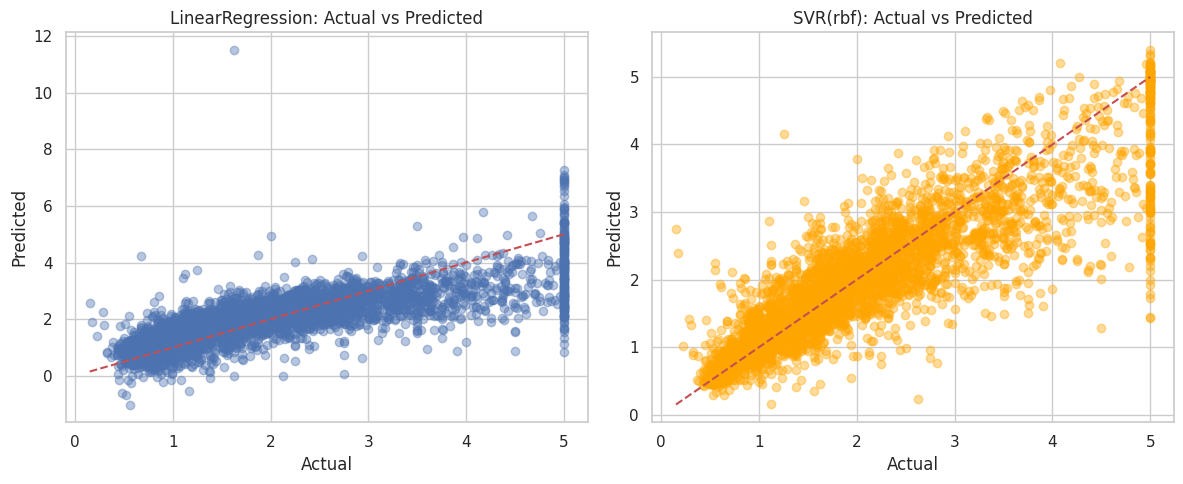

In [7]:
# 문제 3: 산점도 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_reg, pred_lr, alpha=0.4)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[0].set_title('LinearRegression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test_reg, pred_svr, alpha=0.4, color='orange')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[1].set_title('SVR(rbf): Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


### 문제 3 해석 작성
- (작성) 선형 모델의 한계가 드러난 패턴
- (작성) SVR 성능 개선 이유(비선형 함수 언급)

**답안:**

1. 선형 모델인 왼쪽 파란색 산점도에서, 데이터가 직선을 따라 고르게 분포하지 못하고 특정 구간에서 평평하게 눕거나 흩어지는 경향이 보입니다. 즉, 과소적합이 나타납니다.

2. SVR 성능 개선 이유는 데이터를 고차원 공간으로 보낸 뒤, 복잡한 비선형적 경계를 찾았기 때문에 더 밀집하게 분포되어있습니다. SVR은 비선형 함수를 통해 유연하게 학습하며 예측 정확도를 높입니다.

### 문제 4
SVR의 `C`, `epsilon`을 바꿔 성능 변화를 관찰하고, 과적합 방지 전략을 설명하세요.


In [8]:
# 문제 4: 하이퍼파라미터 실험
C_list = [1, 10, 50]
eps_list = [0.01, 0.1, 0.3]

rows = []
for c in C_list:
    for eps in eps_list:
        # TODO 11) 루프 변수 c, eps를 SVR에 적용
        model = SVR(kernel='rbf', C=c, epsilon=eps)
        model.fit(X_train_reg_scaled, y_train_reg)
        pred = model.predict(X_test_reg_scaled)
        rows.append({
            'C': c,
            'epsilon': eps,
            'MSE': mean_squared_error(y_test_reg, pred),
            'R2': r2_score(y_test_reg, pred)
        })

# TODO 12) R2 기준 내림차순
svr_grid_result = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
svr_grid_result


,C,epsilon,MSE,R2
0,50,0.30,0.309483,0.763827
1,50,0.10,0.316295,0.758629
2,50,0.01,0.318321,0.757083
3,10,0.30,0.319304,0.756333
4,10,0.10,0.323697,0.752980
5,10,0.01,0.324228,0.752575
6,1,0.30,0.352804,0.730768
7,1,0.10,0.357004,0.727563
8,1,0.01,0.357802,0.726954


### 문제 4 해석 작성
- (작성) `C` 증가/감소가 편향 및 분산에 미치는 영향
- (작성) `epsilon` 변화가 예측 민감도에 미치는 영향
- (작성) 결론 작성(과적합 방지 전략)

**답안:**

1. C 값이 증가하면, 모델은 개발 오차를 허용하지 않고 학습 데이터에 맞추려고 합니다. 즉, 편향을 낮추어 정확도를 높이지만 분산이 커지는 과적합이 나타납니다. 반면, C 값이 감소하면, 데이터 오차를 허용하며 단순해집니다. 분산을 낮추어 성능 높일 수 있지만 너무 작으면 편향 상승이 발생할 수 있습니다.

2. epilon이 0.01에 가까울수록 모델은 작은 오차에도 예민하게 반응합니다. 모델이 더 복잡하고 민감한 예측을 합니다. 반면, epsilon이 0.30일때 가장 좋은 성능이 나옵니다. 즉, 어느 정도의 오차 허용 범위를 두는 것이 예측 민감도를 적절히 억제합니다.

3. 과적합을 방지하기 위해서는 단순히 C를 높이는 것에만 초점을 두는 것보다 교차 검증을 이용하여 편향과 분산이 균형을 이루는 지점을 찾아야 합니다. 또한 epsilon을 조정함으로써 모델의 불필요한 예민함을 제어하며 방지합니다.



## [Section 3] Decision Tree & Ensemble

### 문제 5
`DecisionTreeRegressor` vs `RandomForestRegressor` 성능 비교


In [9]:
# 문제 5: Bagging 비교
dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

# TODO 13) DecisionTree 학습 메서드
dt.fit(X_train_reg, y_train_reg)
# TODO 14) RandomForest 학습 메서드
rf.fit(X_train_reg, y_train_reg)
pred_dt = dt.predict(X_test_reg)
pred_rf = rf.predict(X_test_reg)

result_q5 = pd.DataFrame({
    'Model': ['DecisionTreeRegressor', 'RandomForestRegressor'],
    'MSE': [mean_squared_error(y_test_reg, pred_dt), mean_squared_error(y_test_reg, pred_rf)],
    'R2': [r2_score(y_test_reg, pred_dt), r2_score(y_test_reg, pred_rf)]
})
result_q5


,Model,MSE,R2
0,DecisionTreeRegressor,0.422045,0.677928
1,RandomForestRegressor,0.272759,0.791852


### 문제 5 해석 작성
- (작성) 왜 Random Forest가 단일 트리보다 Variance를 줄이는가?
- (작성) Diversity Theorem 관점에서 샘플 및 특성 랜덤성의 역할

**답안:**

1. 단일 트리는 훈련 데이터의 작은 노이즈나 변화에도 민감하게 반응하여 형태가 크게 변하는 높은 Variance 문제를 가집니다. 반면, Random Forest는 여러 개의 독립적인 나무를 병렬로 학습시킨 뒤 그 결과를 평균냅니다.

2. 샘플 랜덤성은 전체 데이터가 아닌 무작위로 복원 추출된 샘플로 학습하여 모델 간의 다양성을 확보합니다. 특성 랜덤성은 노드를 분할할 때 무작위로 선택된 일부 특성 중에서 최적의 분할을 찾습니다.


### 문제 6
Boosting 성능 비교 및 Residual 학습 원리


In [10]:
# 문제 6: Boosting
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=3)

# TODO 15) GradientBoosting 학습 메서드
gbr.fit(X_train_reg, y_train_reg)
# TODO 16) GradientBoosting 예측 메서드
pred_gbr = gbr.predict(X_test_reg)

result_q6 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)', 'DecisionTreeRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MSE': [
        mean_squared_error(y_test_reg, pred_lr),
        mean_squared_error(y_test_reg, pred_svr),
        mean_squared_error(y_test_reg, pred_dt),
        mean_squared_error(y_test_reg, pred_rf),
        mean_squared_error(y_test_reg, pred_gbr)
    ],
    'R2': [
        r2_score(y_test_reg, pred_lr),
        r2_score(y_test_reg, pred_svr),
        r2_score(y_test_reg, pred_dt),
        r2_score(y_test_reg, pred_rf),
        r2_score(y_test_reg, pred_gbr)
    ]
}).sort_values('R2', ascending=False).reset_index(drop=True)
result_q6


,Model,MSE,R2
0,RandomForestRegressor,0.272759,0.791852
1,GradientBoostingRegressor,0.291214,0.777768
2,SVR(rbf),0.323697,0.752980
3,DecisionTreeRegressor,0.422045,0.677928
4,LinearRegression,0.555892,0.575788


### 문제 6 해석 작성
- (작성) GBM이 이전 단계 잔차를 어떤 방식으로 학습하는지 단계별로 설명
- (작성) 위 실험에서의 GBM과 랜덤포레스트의 성능(R2) 차이를 Bias-Variance Trade-off로 해석

**답안:**

1.
 - 초기화 단계: 타겟 값의 평균과 같은 단순한 모델로 시작하여 첫 번째 예측을 수행한다.
 - 잔차 계산: 실제 정답과 현재 모델의 예측값 사이의 차이를 계산한다.
 - 잔차 학습: 새로운 트리 모델을 만들어서 원본 데이터가 아닌 이전 단계의 잔차를 맞추도록 학습시킨다.
 - 학습된 잔차 예측값에 learning rate를 곱하여 기존 예측값에 더함으로써 모델을 점진적으로 업데이트한다.


 2. Random Forest는 독립적으로 학습시켜 평균을 내는 방식입니다. 개별 나무의 오차를 상쇄하여 분산을 낮추는 데 최적화되어 있습니다. GBM은 이전 모델의 오차를 보정하며 학습하는 방식입니다. 모델을 점점 더 복잡하게 만들어 편향을 낮추는 데에 초점을 둡니다.

## [Section 4] 결론 및 분석

### 문제 7
분류 문제에서 Accuracy가 아닌 F1-score가 중요한 상황을 확인하세요.


In [12]:
# 문제 7: 분류
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE,
    # TODO 17) 클래스 비율 유지를 위한 설정
    stratify=y_clf
)

scaler_clf = StandardScaler()
# TODO 18) 분류 데이터 학습 스케일링 메서드
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

from sklearn.ensemble import RandomForestClassifier
clf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
clf_model.fit(X_train_clf, y_train_clf)
pred_clf = clf_model.predict(X_test_clf)

print('Accuracy:', accuracy_score(y_test_clf, pred_clf))
print('F1-macro:', f1_score(y_test_clf, pred_clf, average='macro'))
print('F1-weighted:', f1_score(y_test_clf, pred_clf, average='weighted'))
print('\nClassification Report\n', classification_report(y_test_clf, pred_clf))


Accuracy: 1.0
F1-macro: 1.0
F1-weighted: 1.0

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### 문제 7 해석 작성
- (작성) Accuracy가 왜 클래스 불균형 데이터에서 왜곡될 수 있는지
- (작성) F1-score를 Accuracy보다 우선 확인해야 하는 상황 예시 (앞 문항과 연결하여 작성)

**답안:**

1. 데이터셋에서 특정 클래스가 99%를 차지하고 있다면, 모델이 아무런 학습 없이 모든 데이터를 해당 다수 클래스로만 예측해도 Accuracy는 99%가 나옵니다. 이 경우 모델의 실제 식별 능력은 형편없음에도 불구하고 수치상으로는 완벽해 보이게 되어 왜곡이 발생합니다.

2. F1-score는 정밀도와 재현율의 조화 평균이므로, 클래스 불균형이 심할수록 소수 클래스를 얼마나 정확하게 아는지 정확도보다 훨씬 잘 보여줍니다. 모델의 신뢰성을 평가하기 위해서 F1-score 확인이 우선시됩니다.


### 문제 8
최종 선택 모델의 Feature Importance를 출력하고 도메인 관점으로 왜 이러한 결과가 나왔는지 생각해보세요 ^ㅡ^


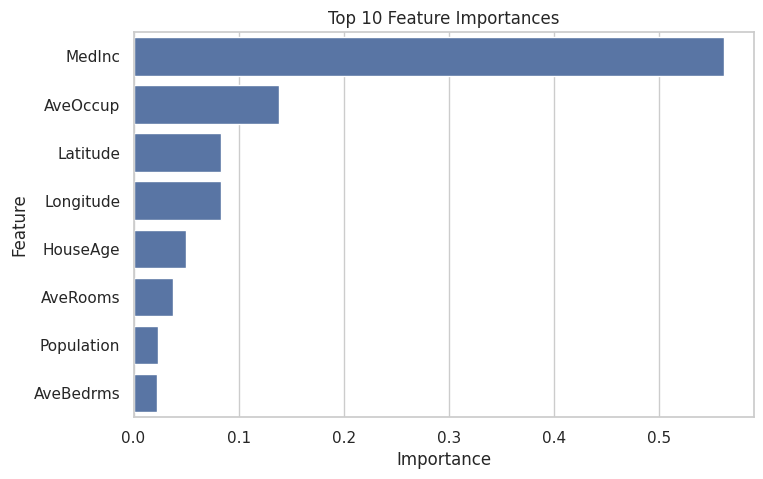

,0
MedInc,0.561583
AveOccup,0.138812
Latitude,0.083399
Longitude,0.083280
HouseAge,0.050154
AveRooms,0.037396
Population,0.022901
AveBedrms,0.022474


In [13]:
# 문제 8: 특성 중요도 시각화
final_model = rf
importance = pd.Series(final_model.feature_importances_, index=X_train_reg.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values[:10], y=importance.index[:10], orient='h')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

importance.head(10)


## 제출 전 체크리스트
- [ ] Section 1~4 모든 코드 작성 및 실행
- [ ] 서술형 문항 답안 작성


긴 과제 진행하시느라 정말 고생 많으셨습니다.

코드작성과 해석을 스스로 정리해보신 만큼, 지도학습 핵심 개념을 탄탄하게 가져가는 기회가 되셨으면 합니다.
감사합니다.
